# GR Project 1: Interactive Spacetime Visualizer


The goal of this project is to create an interactiv graph of Minkowski space in one spatial dimension. There are a few features I aim to incorporate:

1. Place events on a graph DONE
2. add observers at different velocities DONE
3. watch coordinates transform between reference frames DONE
4. see simultaneity change
5. measure proper time along worldlines
6. display light cones  DONE

This is a robust list of features, and will allow for a lot of interactivity.

### Constructing the Class

In [269]:
import matplotlib.pyplot as plt
import numpy as np

class minkowski_space:
    """Construct a graph of Minkowski Space in one spatial dimension.
    Units of c = 1.
    """
    def __init__(self, length=10):
        """Initialize a blank graph of Minkowski space.

        PARAMETERS
        ----------
        length: (int)
            defines the length of each axis. The default is 10
        """
        #imports
        import matplotlib.pyplot as plt

        self.length = length

        
        #construct the figure
        plt.figure(figsize=(6,6))
        plt.xlim(-length, length)
        plt.ylim(-length, length)
        plt.xlabel("x")
        plt.ylabel("t")
        plt.grid()
        plt.legend()


    def events(event):
        """This method plots events on the graph, representing them as 
        red dots. 

        PARAMETERS
        ----------
        event: (array)
            An array of two elements holding the coordinates of the event (x,t)

        OUTPUTS
        -------
        f
        """
        #plot the event
        plt.plot(event[0], event[1],'ro')

        return

    def worldlines(event, v):
        """This method defines the worldlines traced out by different events in the graph
    
        PARAMETERS
        ----------
        event: (array)
            The coordinates of the event (x,t)
        v: (float)
            The constant velocity that the obserer is travelling at
    
        OUTPUTS
        -------
        positions: 
            the positions of the respective event
    
        times: (array)
            the time coordinates of the worldline of the respective event
        """
        #define the worldine of the observer s.t. the event is the starting point
        #because we are only working with constant velocities, they will be straight lines
        
        #define the times that are relevant for this event:
        times = np.arange(0,10)
    
        #define the equation of the worldline
        pos = v*times

        #the +event[] is to move the worldline to the initial position of the event
        pos += event[0]
        times += event[1]

        #plot the worldline
        plt.plot(pos, times, 'r') 
    
        return pos, times

    def lightcones(event):
        """This method plots ligthcones at a desired event.
        Light cones are the surface drawn by null paths from a desired event. In 2 spatial
        dimensions, it takes the shape of a double cone, where it gets its name.
        Notice that these do not change under lorentz transformations

        PARAMETERS
        ----------
        event: (array)
            The coordinates of the event (x,t)

        OUTPUTS
        -------
        F
        """
        #First, we define equations for null paths in 1 spatial dimension
        # x = +/-t

        x = np.arange(-5,5) #create an array of integers from -10 to 10
        t = np.arange(-5,5)

        #next, we shift these worldlines s.t. their intersection is at the given event
        x += event[0]

        #now we plot both equations
        plt.plot(x,t+event[1], 'r', ls='--')  #the +event[1] is the shift for the time coordinates
        plt.plot(x,-t+event[1], 'r', ls='--')

        return

    def lorentz_transform(v,x,t,event):
        """This method applies a boost of a given velocity to the frame. This is done
        using the following equations:

        x_prime = gamma*(x-v*t)
        t_prime = gamma*(t-v*x)

        gamma = 1/(1-v**2)**(1/2)  The lorentz factor
        
        PARAMETERS
        ----------
        v: float
            the velocity of the boost applied
        x: array
            the postion coordinates to be transformed
        t: array
            the time coordinates to be transformed
        event: array
            The coordinates of the given worldline in the original,
            non-transformed coordinates

        OUTPUTS
        -------
        x_prime: array
            The transformed position coordinates
        t_prime: array
            the transformed time coordinates
        """

        #define the lorentz factor
        gamma = 1/(1-v**2)**(1/2)

        #removing shift ininitial position
        x -= event[0]
        t -= event[1]

        #calculate the transformed coordinates:
        x_prime = gamma*(x-v*t)
        t_prime = gamma*(t-v*x)

        #reapplying shift in initial position
        x_prime += event[0]
        t_prime += event[1]

        #plot transformed worldline as a blue line
        plt.plot(x_prime, t_prime, 'b') 
            
        return x_prime, t_prime
        
    

### Testing

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(array([-1.        , -1.94345635, -2.88691271, -3.83036906, -4.77382541,
        -5.71728177, -6.66073812, -7.60419447, -8.54765082, -9.49110718]),
 array([-4.        , -2.76302389, -1.52604779, -0.28907168,  0.94790443,
         2.18488054,  3.42185664,  4.65883275,  5.89580886,  7.13278497]))

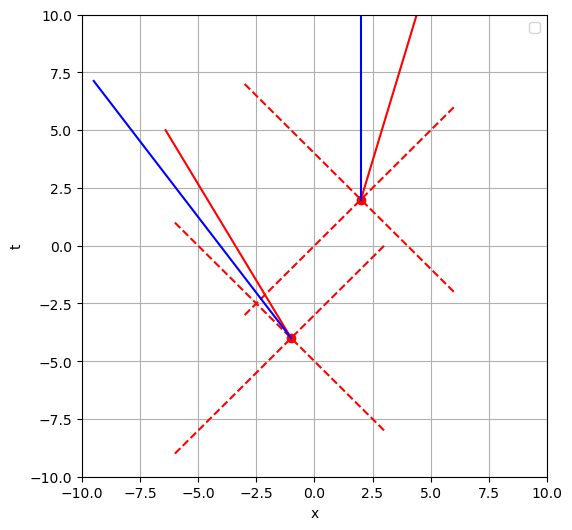

In [272]:
minkowski_space()

#define an event at (5,5)
event  = [2,2]
#plot the event
minkowski_space.events(event)

#now we add a worldline for the respective event
#define a velocity (recall units of c=1)
v = 0.3
pos, t = minkowski_space.worldlines(event, v)

minkowski_space.lightcones(event)


#lets try plotting another event and worldline
event_0 = [-1,-4]
v_0 = -0.6

minkowski_space.events(event_0)
pos_0, t_0 = minkowski_space.worldlines(event_0,v_0)

#plot the lightcones of an event
minkowski_space.lightcones(event_0)

#boost each of the events 
minkowski_space.lorentz_transform(v,pos,t,event)
minkowski_space.lorentz_transform(v,pos_0,t_0,event_0)